<a href="https://colab.research.google.com/github/kaveeshahq/research-project/blob/main/wine_quality_lstm_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib shap imbalanced-learn xgboost lightgbm

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [ ]:
print("Loading dataset...")
df = pd.read_csv('winequality-white.csv', sep=';')
print("Dataset columns:", df.columns.tolist())
print("Dataset shape:", df.shape)

Loading dataset...
Dataset columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Dataset shape: (4898, 12)


In [ ]:
df = df.copy()

if 'fixed acidity' in df.columns and 'volatile acidity' in df.columns:
    df['acid_ratio'] = df['fixed acidity'] / (df['volatile acidity'] + 1e-6)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
import numpy as np

X_train = np.array(X_train)
X_test = np.array(X_test)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (3918, 12, 1)
Testing shape: (980, 12, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [ ]:
model = Sequential()

model.add(LSTM(64, input_shape=(X_train.shape[1], 1), return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [2]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("LSTM Results")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

NameError: name 'y_test' is not defined

In [ ]:
model = Sequential()

model.add(LSTM(64, input_shape=(X_train.shape[1], 1), return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 20.0585 - mae: 3.8740 - val_loss: 0.7387 - val_mae: 0.6555
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.9669 - mae: 0.7704 - val_loss: 0.7135 - val_mae: 0.6443
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.9403 - mae: 0.7581 - val_loss: 0.6945 - val_mae: 0.6279
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.8691 - mae: 0.7240 - val_loss: 0.7112 - val_mae: 0.6412
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.8177 - mae: 0.7128 - val_loss: 0.6737 - val_mae: 0.6261
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.8198 - mae: 0.7183 - val_loss: 0.6403 - val_mae: 0.6023
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.7791 - mae: 0.7005 - val_loss: 0.6299 - val_mae: 0.6001
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.7508 - mae: 0.6833 - val_loss: 0.6314 - val_mae: 0.6026
Epoch 9/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.7457 -

In [ ]:
y_pred = model.predict(X_test)
y_pred = y_pred.flatten()

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("LSTM Results")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

LSTM Results
RMSE: 0.794942532207698
MAE: 0.6125355958938599
R2: 0.1840469241142273


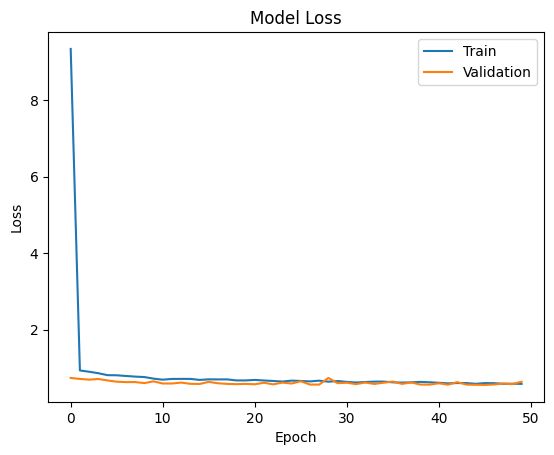

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()

In [ ]:
TARGET = 'quality'

X = df.drop(columns=[TARGET])
y = df[TARGET].values

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("winequality-white.csv", sep=";")

FileNotFoundError: [Errno 2] No such file or directory: 'winequality-white.csv'

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving winequality-white.csv to winequality-white.csv


In [ ]:
df = pd.read_csv("winequality-white.csv", sep=";")

In [ ]:
X = df.drop("quality", axis=1)
y = df["quality"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)